<a href="https://colab.research.google.com/github/brknatmaca/group-5---Analyzing-Global-CO2-Emissions-and-the-Renewable-Energy-Transition-/blob/main/samsung2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [5]:
df = pd.read_csv('sustainable_energy.csv')

df_cleaned = df.drop(columns=['Financial flows to developing countries (US $)', 'Renewables (% equivalent primary energy)'], errors='ignore')
df_cleaned = df_cleaned.sort_values(by=['Entity', 'Year'])
numeric_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns

In [8]:
for col in numeric_cols:
    df_cleaned[col] = df_cleaned.groupby('Entity')[col].transform(lambda x: x.interpolate(method='linear', limit_direction='both').fillna(x.median()))
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())


--- Top 10 Highest Correlations ---
Value_co2_emissions_kt_by_country                                 Electricity from fossil fuels (TWh)                   0.989270
Access to clean fuels for cooking                                 Access to electricity (% of population)               0.867734
Value_co2_emissions_kt_by_country                                 Electricity from renewables (TWh)                     0.858484
Electricity from renewables (TWh)                                 Electricity from fossil fuels (TWh)                   0.845103
Renewable energy share in the total final energy consumption (%)  Access to clean fuels for cooking                    -0.788789
                                                                  Access to electricity (% of population)              -0.782845
Land Area(Km2)                                                    Electricity from renewables (TWh)                     0.704967
gdp_per_capita                                              

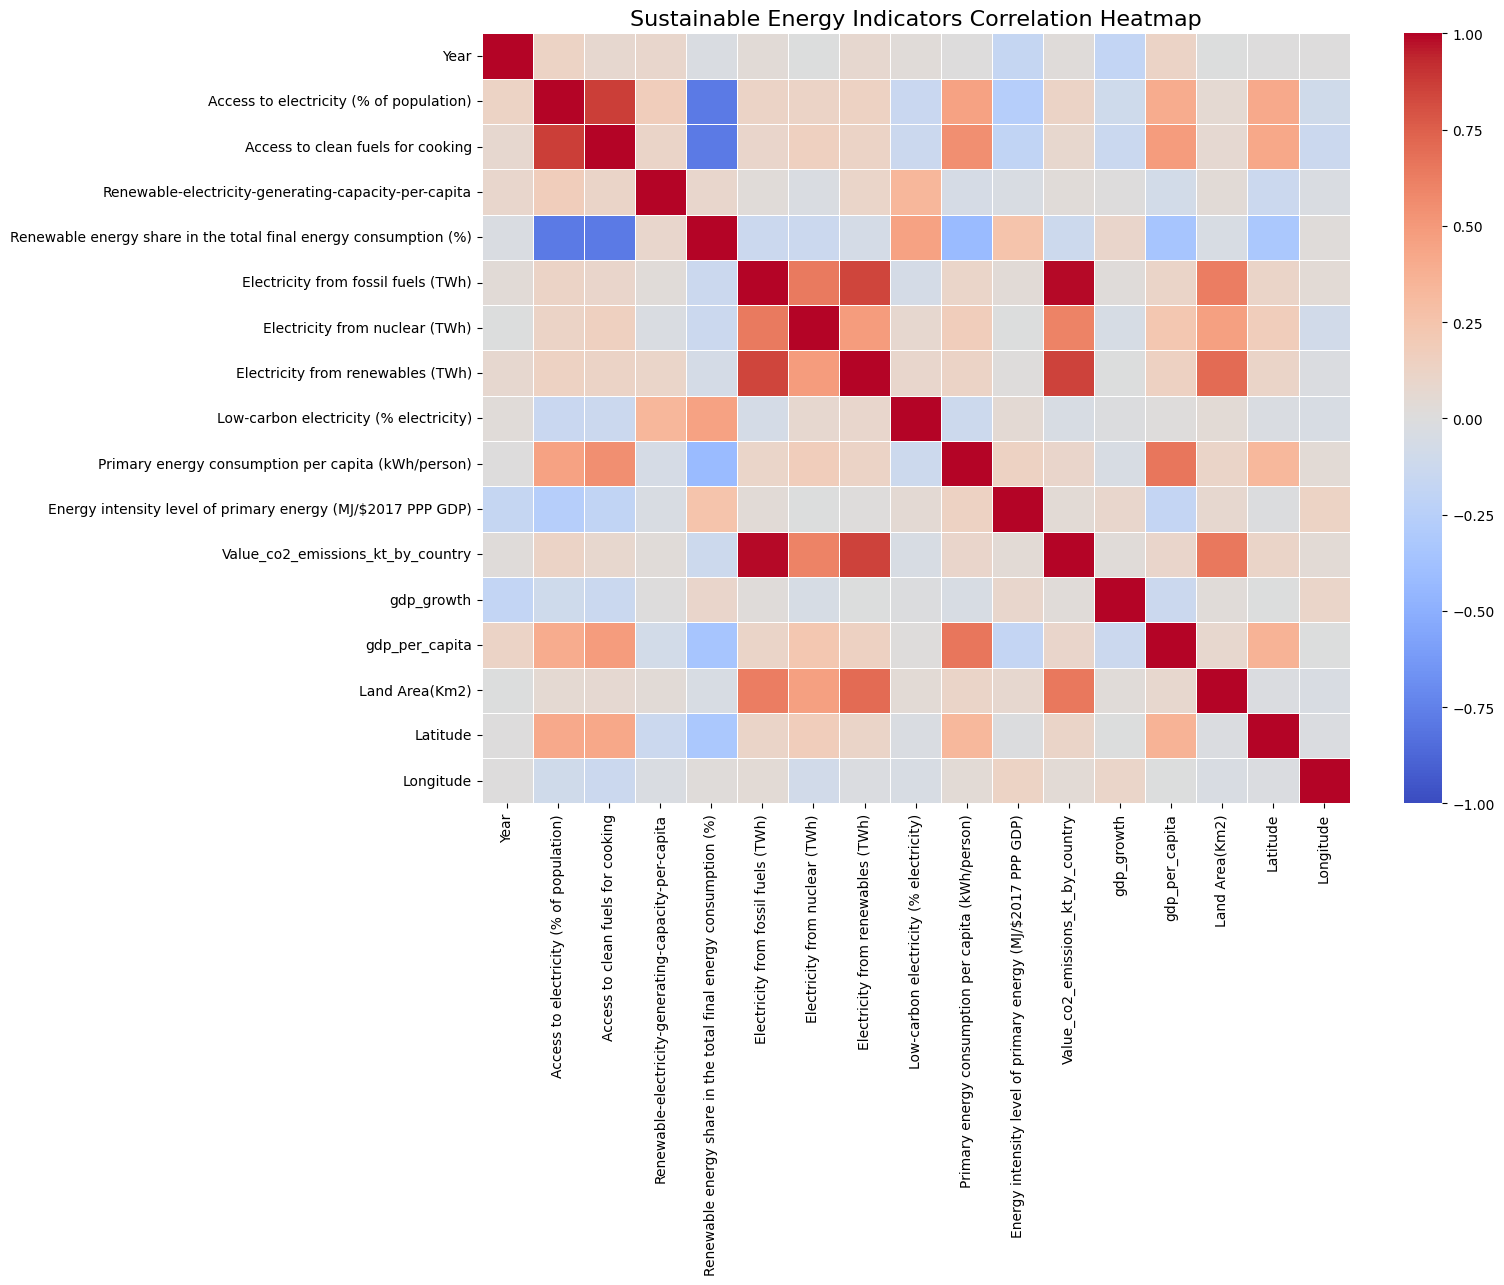

In [10]:
pd.reset_option('display.float_format')
corr_matrix = df_cleaned[numeric_cols].corr()
print("\n--- Top 10 Highest Correlations ---")
upper_corr = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
print(upper_corr.unstack().dropna().sort_values(ascending=False, key=abs).head(10).to_string())

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Sustainable Energy Indicators Correlation Heatmap', fontsize=16)
plt.show()


In [13]:
target_col = 'Value_co2_emissions_kt_by_country'
threshold = 0.85
columns_to_drop = [col for col in upper_corr.columns if any(upper_corr.abs()[col] > threshold)]
if target_col in columns_to_drop:
    columns_to_drop.remove(target_col)

df_cleaned = df_cleaned.drop(columns=columns_to_drop, errors='ignore')
print(f"\nColumns dropped due to high correlation (>0.85): {columns_to_drop}")



Columns dropped due to high correlation (>0.85): ['Access to clean fuels for cooking']


In [16]:
existing_numeric_cols = [c for c in numeric_cols if c in df_cleaned.columns]
print("\n--- Descriptive Statistics ---")
display(df_cleaned[existing_numeric_cols].describe().T)

print("\n--- Skewness Analysis ---")
print(df_cleaned[existing_numeric_cols].skew().sort_values(ascending=False))




--- Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
Year,3649.0,2010.038367,6.054228e+00,2000.000000,2005.000000,2010.000000,2015.000000,2.020000e+03
Access to electricity (% of population),3649.0,78.750760,3.047191e+01,1.252269,59.137558,98.272340,100.000000,1.000000e+02
Renewable-electricity-generating-capacity-per-capita,3649.0,92.668383,2.136031e+02,0.000000,8.390000,32.910000,67.600000,3.060190e+03
Renewable energy share in the total final energy consumption (%),3649.0,32.507096,2.970487e+01,0.000000,6.700000,23.325000,54.670000,9.604000e+01
Electricity from fossil fuels (TWh),3649.0,69.977144,3.470861e+02,0.000000,0.300000,2.970000,26.520000,5.184130e+03
Electricity from nuclear (TWh),3649.0,12.985755,7.177678e+01,0.000000,0.000000,0.000000,0.000000,8.094100e+02
Electricity from renewables (TWh),3649.0,23.838534,1.041440e+02,0.000000,0.050000,1.470000,9.560000,2.184940e+03
Low-carbon electricity (% electricity),3649.0,36.698327,3.413009e+01,0.000000,3.030303,27.865068,64.022670,1.000000e+02
Primary energy consumption per capita (kWh/person),3649.0,25743.981745,3.477322e+04,0.000000,3116.737300,13120.570000,33892.780000,2.625857e+05
Energy intensity level of primary energy (MJ/$2017 PPP GDP),3649.0,5.252228,3.486272e+00,0.110000,3.160000,4.280000,5.970000,3.257000e+01



--- Skewness Analysis ---
Electricity from renewables (TWh)                                   11.088766
Value_co2_emissions_kt_by_country                                    9.752190
Electricity from fossil fuels (TWh)                                  9.424156
Electricity from nuclear (TWh)                                       8.720780
Renewable-electricity-generating-capacity-per-capita                 6.244236
Land Area(Km2)                                                       4.635739
Primary energy consumption per capita (kWh/person)                   2.651621
Energy intensity level of primary energy (MJ/$2017 PPP GDP)          2.608681
gdp_growth                                                           2.556781
gdp_per_capita                                                       2.471683
Renewable energy share in the total final energy consumption (%)     0.682528
Low-carbon electricity (% electricity)                               0.517231
Year                                 

<Figure size 1500x700 with 0 Axes>

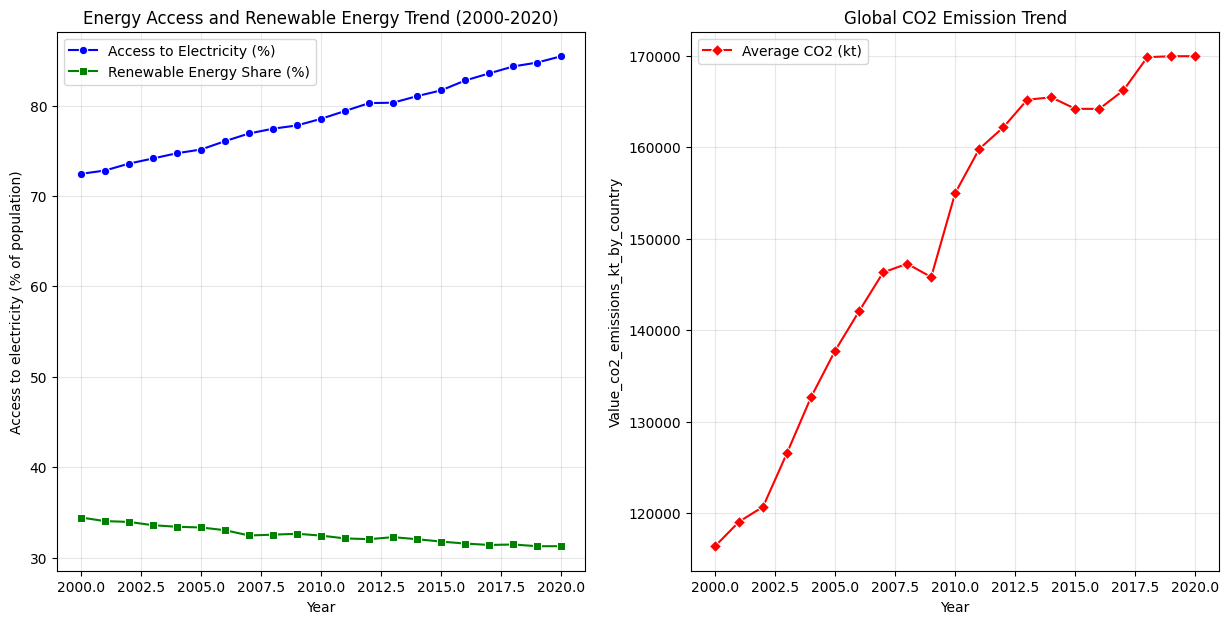

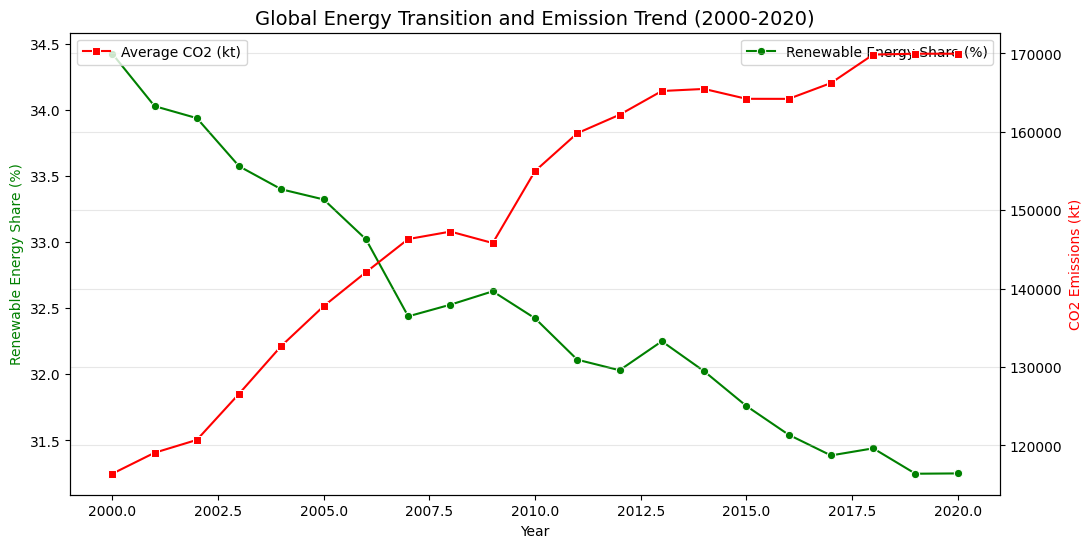

In [18]:
plt.figure(figsize=(15, 7))
agg_dict = {c: 'mean' for c in ['Access to electricity (% of population)', 'Renewable energy share in the total final energy consumption (%)', target_col] if c in df_cleaned.columns}
trend_df = df_cleaned.groupby('Year').agg(agg_dict).reset_index()

plt.subplot(1, 2, 1)
if 'Access to electricity (% of population)' in trend_df.columns:
    sns.lineplot(data=trend_df, x='Year', y='Access to electricity (% of population)', marker='o', label='Access to Electricity (%)', color='blue')
if 'Renewable energy share in the total final energy consumption (%)' in trend_df.columns:
    sns.lineplot(data=trend_df, x='Year', y='Renewable energy share in the total final energy consumption (%)', marker='s', label='Renewable Energy Share (%)', color='green')
plt.title('Energy Access and Renewable Energy Trend (2000-2020)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
if target_col in trend_df.columns:
    sns.lineplot(data=trend_df, x='Year', y=target_col, marker='D', color='red', label='Average CO2 (kt)')
plt.title('Global CO2 Emission Trend')
plt.grid(True, alpha=0.3)
plt.show()


if target_col in df_cleaned.columns and 'Renewable energy share in the total final energy consumption (%)' in df_cleaned.columns:
    plt.figure(figsize=(12, 6))
    trend_data = df_cleaned.groupby('Year')[['Renewable energy share in the total final energy consumption (%)', target_col]].mean().reset_index()
    ax1 = sns.lineplot(data=trend_data, x='Year', y='Renewable energy share in the total final energy consumption (%)', color='green', label='Renewable Energy Share (%)', marker='o')
    ax2 = ax1.twinx()
    sns.lineplot(data=trend_data, x='Year', y=target_col, color='red', label='Average CO2 (kt)', marker='s', ax=ax2)
    ax1.set_title('Global Energy Transition and Emission Trend (2000-2020)', fontsize=14)
    ax1.set_ylabel('Renewable Energy Share (%)', color='green')
    ax2.set_ylabel('CO2 Emissions (kt)', color='red')
    plt.grid(True, alpha=0.3)
    plt.show()

In [19]:
X = df_cleaned.select_dtypes(include=[np.number]).drop(columns=[target_col], errors='ignore')
y = df_cleaned[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
min_max_cols = [c for c in ['Access to electricity (% of population)', 'Access to clean fuels for cooking', 'Renewable energy share in the total final energy consumption (%)', 'Low-carbon electricity (% electricity)'] if c in X_train.columns]
if min_max_cols:
    minmax_scaler = MinMaxScaler()
    X_train.loc[:, min_max_cols] = minmax_scaler.fit_transform(X_train[min_max_cols])
    X_test.loc[:, min_max_cols] = minmax_scaler.transform(X_test[min_max_cols])

standard_cols = [c for c in ['gdp_per_capita', 'Primary energy consumption per capita (kWh/person)', 'Renewable-electricity-generating-capacity-per-capita'] if c in X_train.columns]
if standard_cols:
    std_scaler = StandardScaler()
    X_train.loc[:, standard_cols] = std_scaler.fit_transform(X_train[standard_cols])
    X_test.loc[:, standard_cols] = std_scaler.transform(X_test[standard_cols])

In [21]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [22]:
def calculate_advanced_metrics(y_true, y_pred, y_train_data):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    mase = mae / np.mean(np.abs(y_true - np.mean(y_train_data)))
    return r2, mae, rmse, mape, mase

rf_r2, rf_mae, rf_rmse, rf_mape, rf_mase = calculate_advanced_metrics(y_test, rf_preds, y_train)
lr_r2, lr_mae, lr_rmse, lr_mape, lr_mase = calculate_advanced_metrics(y_test, lr_preds, y_train)

print("\n--- Random Forest Model Metrics ---")
print(f"R2 Score : {rf_r2:.4f} | RMSE: {rf_rmse:.2f} | MAE: {rf_mae:.2f} | MAPE: %{rf_mape:.2f} | MASE: {rf_mase:.4f}")

print("\n--- Linear Regression Model Metrics ---")
print(f"R2 Score : {lr_r2:.4f} | RMSE: {lr_rmse:.2f} | MAE: {lr_mae:.2f} | MAPE: %{lr_mape:.2f} | MASE: {lr_mase:.4f}")


--- Random Forest Model Metrics ---
R2 Score : 0.9987 | RMSE: 19287.49 | MAE: 4147.39 | MAPE: %10.85 | MASE: 0.0214

--- Linear Regression Model Metrics ---
R2 Score : 0.9688 | RMSE: 94353.23 | MAE: 37139.67 | MAPE: %2075.49 | MASE: 0.1917


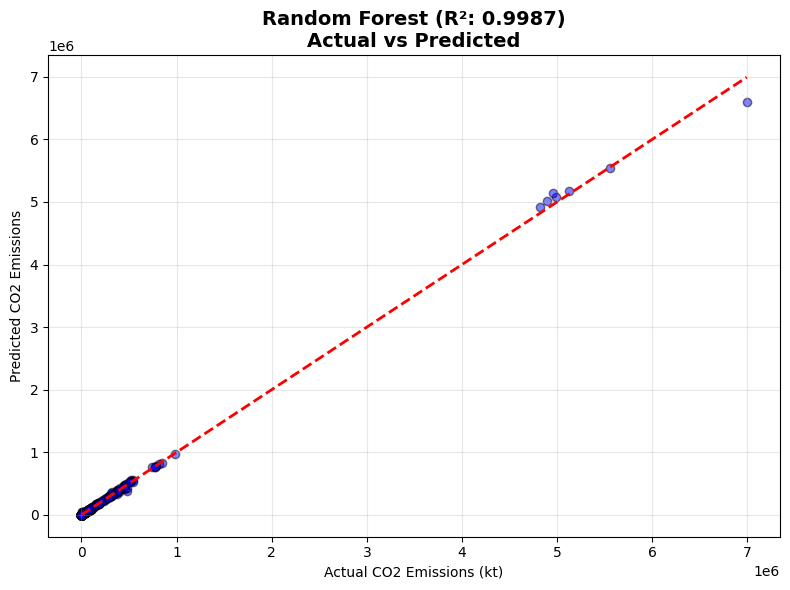

In [23]:
# Random Forest: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_preds, alpha=0.5, color='blue', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Random Forest (R²: {rf_r2:.4f})\nActual vs Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Actual CO2 Emissions (kt)')
plt.ylabel('Predicted CO2 Emissions')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

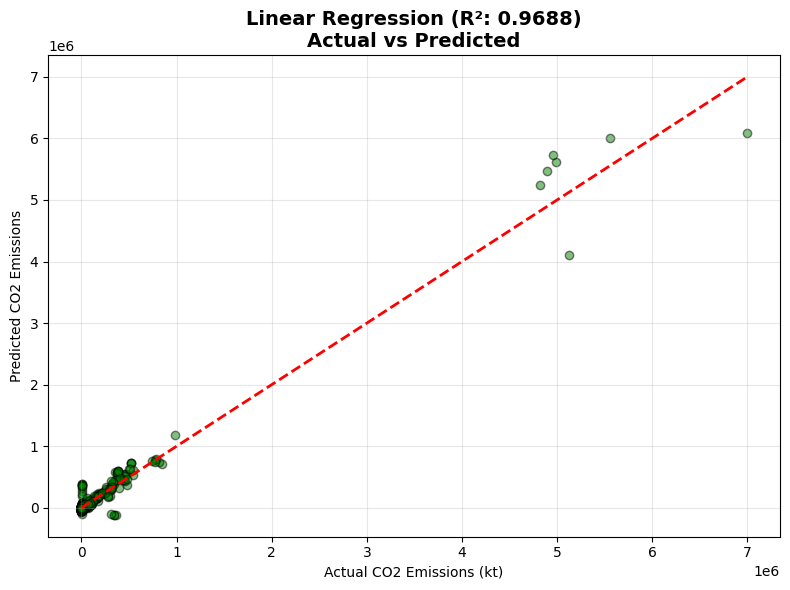

In [24]:
# Linear Regression: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lr_preds, alpha=0.5, color='green', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Linear Regression (R²: {lr_r2:.4f})\nActual vs Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Actual CO2 Emissions (kt)')
plt.ylabel('Predicted CO2 Emissions')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6217/123546156.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances.values, y=rf_importances.index, palette='viridis')


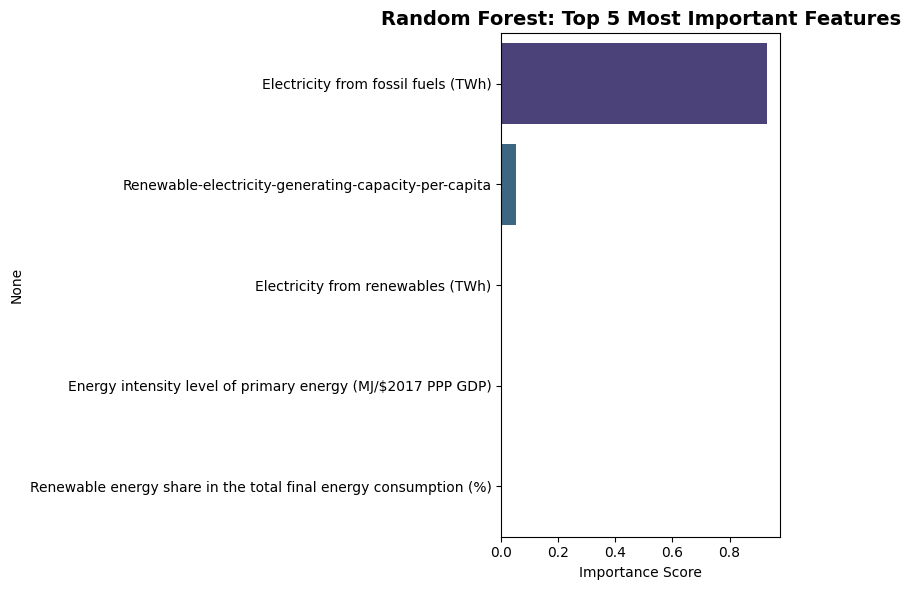

In [25]:
# Random Forest: Feature Importance
plt.figure(figsize=(8, 6))
rf_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(5)
sns.barplot(x=rf_importances.values, y=rf_importances.index, palette='viridis')
plt.title('Random Forest: Top 5 Most Important Features', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6217/3840423048.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_lr_coefs.values, y=top_lr_coefs.index, palette='coolwarm')


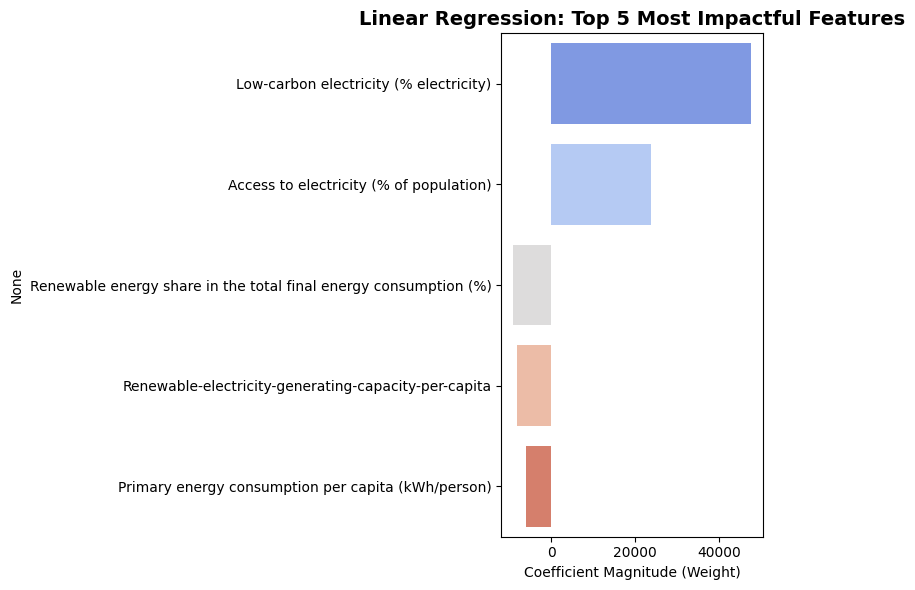

In [26]:
# Linear Regression: Feature Coefficients
plt.figure(figsize=(8, 6))
lr_coefficients = pd.Series(lr_model.coef_, index=X.columns)
top_lr_coefs = lr_coefficients[lr_coefficients.abs().sort_values(ascending=False).head(5).index]
sns.barplot(x=top_lr_coefs.values, y=top_lr_coefs.index, palette='coolwarm')
plt.title('Linear Regression: Top 5 Most Impactful Features', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Magnitude (Weight)')
plt.tight_layout()
plt.show()

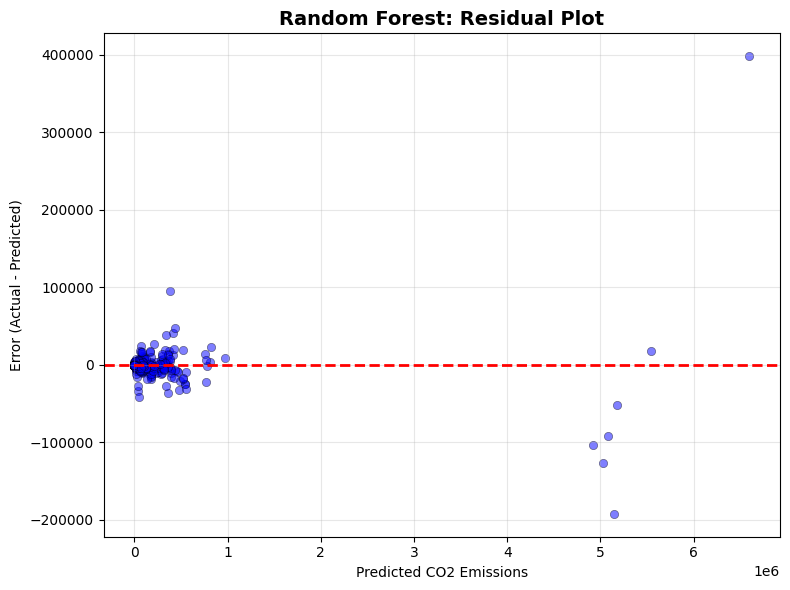

In [27]:
# Random Forest: Residual Plot
rf_residuals = y_test - rf_preds
plt.figure(figsize=(8, 6))
sns.scatterplot(x=rf_preds, y=rf_residuals, color='blue', alpha=0.5, edgecolor='k')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Random Forest: Residual Plot', fontsize=14, fontweight='bold')
plt.xlabel('Predicted CO2 Emissions')
plt.ylabel('Error (Actual - Predicted)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

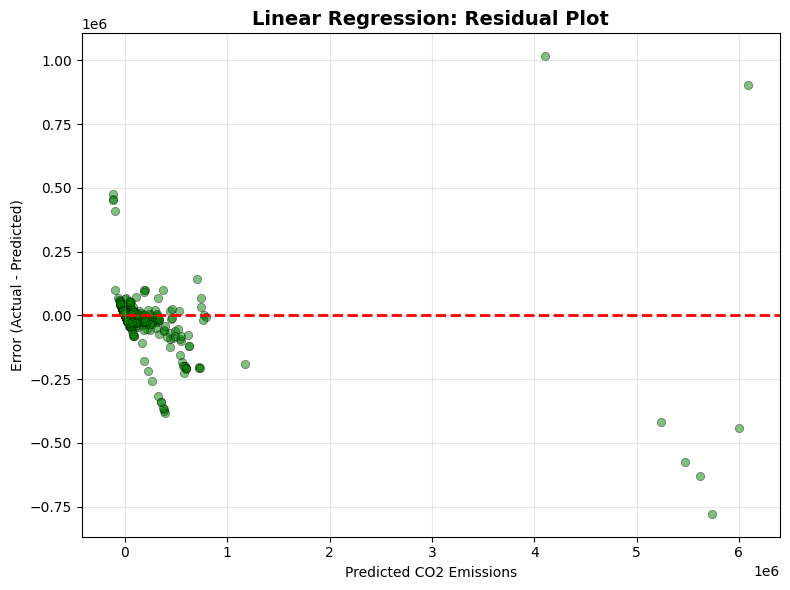

In [28]:
# Linear Regression: Residual Plot
lr_residuals = y_test - lr_preds
plt.figure(figsize=(8, 6))
sns.scatterplot(x=lr_preds, y=lr_residuals, color='green', alpha=0.5, edgecolor='k')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Linear Regression: Residual Plot', fontsize=14, fontweight='bold')
plt.xlabel('Predicted CO2 Emissions')
plt.ylabel('Error (Actual - Predicted)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


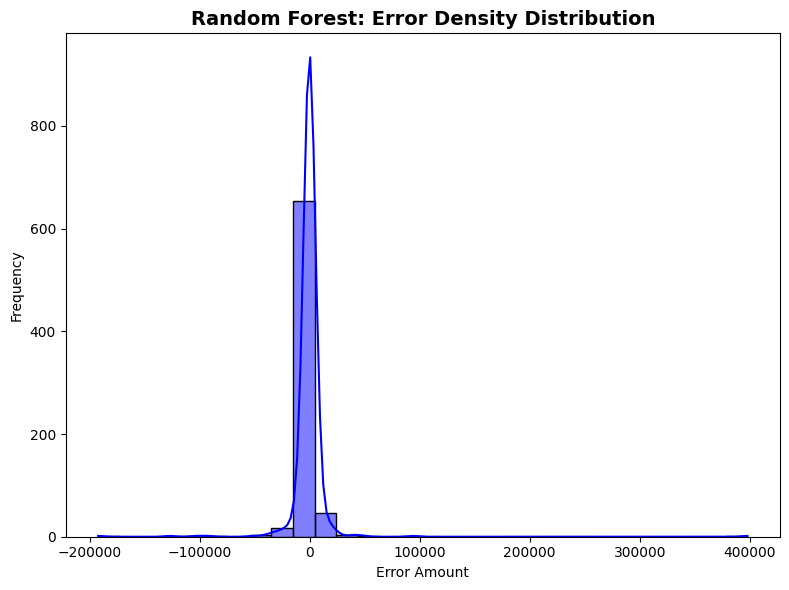

In [29]:
# Random Forest: Error Density Histogram
plt.figure(figsize=(8, 6))
sns.histplot(rf_residuals, kde=True, color='blue', bins=30)
plt.title('Random Forest: Error Density Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Error Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

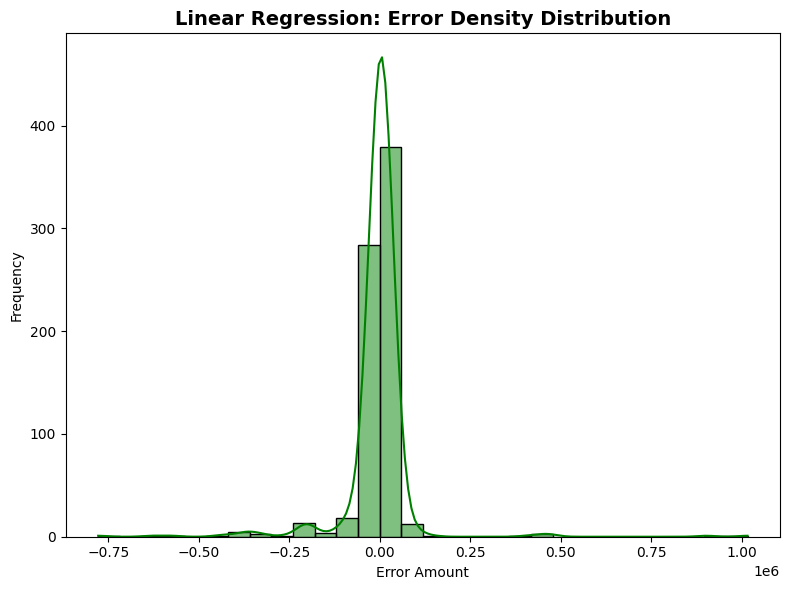

In [30]:
# Linear Regression: Error Density Histogram
plt.figure(figsize=(8, 6))
sns.histplot(lr_residuals, kde=True, color='green', bins=30)
plt.title('Linear Regression: Error Density Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Error Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [34]:
results_df = X_test.copy()
results_df['Actual_CO2'] = y_test
results_df['RF_Pred'] = rf_preds
results_df['LR_Pred'] = lr_preds
results_df['Entity'] = df_cleaned.loc[results_df.index, 'Entity']
results_df['RF_Error'] = abs(results_df['Actual_CO2'] - results_df['RF_Pred'])
results_df['LR_Error'] = abs(results_df['Actual_CO2'] - results_df['LR_Pred'])

pd.options.display.float_format = '{:,.0f}'.format

print("\n[1] Top 5 BEST Predictions by Random Forest:")
print(results_df[['Entity', 'Year', 'Actual_CO2', 'RF_Pred', 'RF_Error']].sort_values(by='RF_Error', ascending=True).head(5).to_string(index=False))

print("\n[2] Top 5 BEST Predictions by Linear Regression:")
print(results_df[['Entity', 'Year', 'Actual_CO2', 'LR_Pred', 'LR_Error']].sort_values(by='LR_Error', ascending=True).head(5).to_string(index=False))

print("\n[3] Top 5 WORST Predictions by Random Forest:")
print(results_df[['Entity', 'Year', 'Actual_CO2', 'RF_Pred', 'RF_Error']].sort_values(by='RF_Error', ascending=False).head(5).to_string(index=False))

print("\n[4] Top 5 WORST Predictions by Linear Regression:")
print(results_df[['Entity', 'Year', 'Actual_CO2', 'LR_Pred', 'LR_Error']].sort_values(by='LR_Error', ascending=False).head(5).to_string(index=False))

neg_preds = results_df[results_df['LR_Pred'] < 0]
if len(neg_preds) > 0:
    print(f"\n[5] Linear Regression predicted NEGATIVE CO2 emissions for {len(neg_preds)} instances")
    print(neg_preds[['Entity', 'Year', 'Actual_CO2', 'LR_Pred']].head(5).to_string(index=False))

print("\n--- Random Forest Accuracy Summary  ---")
rf_percentage_errors = np.abs((y_test - rf_preds) / (y_test + 1e-10)) * 100
total_preds = len(y_test)
print(f"Total Test Data: {total_preds}")
print(f"Perfect Predictions within 1% Error  : {np.sum(rf_percentage_errors <= 1)} ({(np.sum(rf_percentage_errors <= 1)/total_preds)*100:.1f}%)")
print(f"Very Good Predictions within 5% Error: {np.sum(rf_percentage_errors <= 5)} ({(np.sum(rf_percentage_errors <= 5)/total_preds)*100:.1f}%)")
print(f"Successful Predictions within 10% Error: {np.sum(rf_percentage_errors <= 10)} ({(np.sum(rf_percentage_errors <= 10)/total_preds)*100:.1f}%)")


[1] Top 5 BEST Predictions by Random Forest:
     Entity  Year  Actual_CO2  RF_Pred  RF_Error
      Nauru  2009          40       40         0
     Gambia  2002      10,480   10,480         0
      Congo  2008      10,480   10,480         0
    Bahamas  2009      10,480   10,480         0
Saint Lucia  2007      10,480   10,480         0

[2] Top 5 BEST Predictions by Linear Regression:
     Entity  Year  Actual_CO2  LR_Pred  LR_Error
    Bahrain  2005      20,690   20,651        39
     Panama  2008       7,300    7,129       171
El Salvador  2018       6,810    7,010       200
Philippines  2001      70,480   70,738       258
   Slovenia  2017      14,120   14,386       266

[3] Top 5 WORST Predictions by Random Forest:
       Entity  Year  Actual_CO2   RF_Pred  RF_Error
        China  2007   6,993,180 6,595,301   397,879
United States  2012   4,956,060 5,148,349   192,289
United States  2016   4,894,500 5,021,585   127,085
United States  2017   4,819,370 4,922,608   103,237
    Indon